Saved live-play-only table: C:\Users\Zachary\phd_classes\geog572\final\data\processed\player_positions_live_only.csv
1887940 >> 75520 rows after live-play filtering + downsampling
Saved downsampled table: C:\Users\Zachary\phd_classes\geog572\final\data\processed\player_positions_downsampled_1fps_live_only.csv
Saved grouped JSON: C:\Users\Zachary\phd_classes\geog572\final\data\processed\player_itineraries_downsampled_1fps_live_only_huge.json


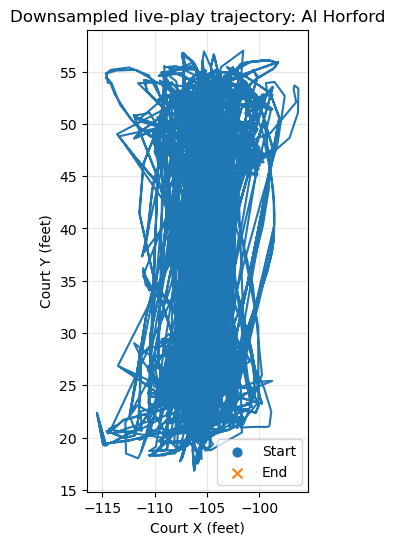

     player_name         x         y    x_vert    y_vert
0    Kyle Korver  45.88531  15.80907  15.80907  45.88531
1   Paul Millsap  60.55955  29.03812  29.03812  60.55955
2     Al Horford  46.27281  24.93825  24.93825  46.27281
3    Jeff Teague  31.06622  23.99459  23.99459  31.06622
4  Kent Bazemore  40.67765  31.85519  31.85519  40.67765


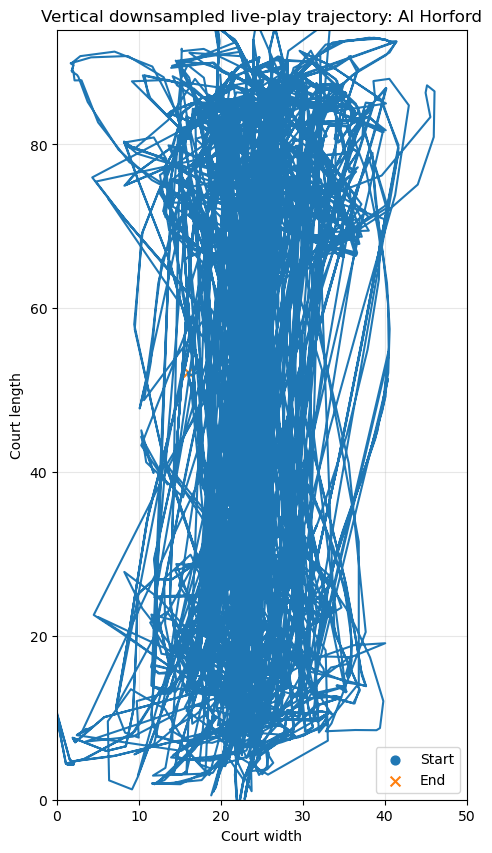

In [5]:
# %%
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# %%
INPUT_JSON = Path("C:\\Users\\Zachary\\phd_classes\\geog572\\final\\data\\external\\0021500001.json")
OUT_CSV = Path("C:\\Users\\Zachary\\phd_classes\\geog572\\final\\data\\processed\\player_positions_live_only.csv")
OUT_DOWNSAMPLED_CSV = Path("C:\\Users\\Zachary\\phd_classes\\geog572\\final\\data\\processed\\player_positions_downsampled_1fps_live_only.csv")
OUT_GROUPED_JSON = Path("C:\\Users\\Zachary\\phd_classes\\geog572\\final\\data\\processed\\player_itineraries_downsampled_1fps_live_only_huge.json")

# %%
with INPUT_JSON.open("r", encoding="utf-8") as f:
    data = json.load(f)

events = data["events"]

# %%
# Build lookup tables for player metadata from home/visitor rosters
player_lookup = {}
team_lookup = {}

if events:
    first_event = events[0]

    for side in ["home", "visitor"]:
        team = first_event[side]
        team_id = team["teamid"]
        team_lookup[team_id] = {
            "team_name": team["name"],
            "team_abbr": team["abbreviation"],
        }

        for p in team["players"]:
            player_lookup[p["playerid"]] = {
                "player_name": f'{p["firstname"]} {p["lastname"]}',
                "jersey": p.get("jersey"),
                "position": p.get("position"),
                "team_id": team_id,
                "team_name": team["name"],
                "team_abbr": team["abbreviation"],
            }

# %%
# Build long table, but keep only live-play frames
# A frame is considered live if the game clock decreased from the previous moment.
# This also automatically drops the first frame in each event.
rows = []
frame_idx = 0          # raw frame index across all moments
live_frame_idx = 0     # frame index only for kept live-play moments

for event in events:
    event_id = event.get("eventId")
    moments = event.get("moments", [])

    prev_game_clock = None

    for moment in moments:
        # moment = [period, wall_time_ms, game_clock, shot_clock, unknown, players_and_ball]
        period = moment[0]
        wall_time_ms = moment[1]
        game_clock = moment[2]
        shot_clock = moment[3]
        players_and_ball = moment[5]

        clock_is_running = (
            prev_game_clock is not None
            and game_clock is not None
            and game_clock < prev_game_clock
        )

        if clock_is_running:
            for obj in players_and_ball:
                team_id, player_id, x, y, z = obj

                # Skip ball
                if team_id == -1 and player_id == -1:
                    continue

                meta = player_lookup.get(player_id, {})
                team_meta = team_lookup.get(team_id, {})

                rows.append({
                    "event_id": event_id,
                    "frame_idx": frame_idx,                # raw frame index
                    "live_frame_idx": live_frame_idx,      # live-play-only frame index
                    "period": period,
                    "wall_time_ms": wall_time_ms,
                    "game_clock": game_clock,
                    "shot_clock": shot_clock,
                    "team_id": team_id,
                    "team_abbr": meta.get("team_abbr", team_meta.get("team_abbr")),
                    "team_name": meta.get("team_name", team_meta.get("team_name")),
                    "player_id": player_id,
                    "player_name": meta.get("player_name"),
                    "jersey": meta.get("jersey"),
                    "position": meta.get("position"),
                    "x": x,
                    "y": y,
                    "z": z,
                })

            live_frame_idx += 1

        prev_game_clock = game_clock
        frame_idx += 1

df = pd.DataFrame(rows)

# %%
# Save tidy long table of live-play-only positions
df.to_csv(OUT_CSV, index=False)
print(f"Saved live-play-only table: {OUT_CSV}")

# %%
# Downsample AFTER filtering live-play frames
# Tracking is ~25 fps, so every 25th live frame is about 1 fps
df_downsampled = df[df["live_frame_idx"] % 25 == 0].copy()

df_downsampled.to_csv(OUT_DOWNSAMPLED_CSV, index=False)

print(len(df), ">>", len(df_downsampled), "rows after live-play filtering + downsampling")
print(f"Saved downsampled table: {OUT_DOWNSAMPLED_CSV}")

# %%
# If you already created a version with x_huge / y_huge, read that here instead.
# Otherwise comment this line out and keep using df_downsampled directly.
df_downsampled = pd.read_csv(
    "C:\\Users\\Zachary\\phd_classes\\geog572\\final\\data\\processed\\player_positions_downsampled_1fps_live_only_huge.csv"
)

# %%
def to_jsonable(value):
    """Convert pandas/numpy scalars to plain Python JSON-safe values."""
    if pd.isna(value):
        return None
    if hasattr(value, "item"):
        return value.item()
    return value

grouped = {}

for player_id, g in df_downsampled.sort_values(["live_frame_idx"]).groupby("player_id"):
    first = g.iloc[0]

    trajectory = []
    for _, row in g.iterrows():
        point = {
            "frame_idx": to_jsonable(row["frame_idx"]),
            "live_frame_idx": to_jsonable(row["live_frame_idx"]),
            "period": to_jsonable(row["period"]),
            "wall_time_ms": to_jsonable(row["wall_time_ms"]),
            "game_clock": to_jsonable(row["game_clock"]),
            "shot_clock": to_jsonable(row["shot_clock"]),
            "x": to_jsonable(row["x"]),
            "y": to_jsonable(row["y"]),
        }

        if "x_huge" in row.index:
            point["x_huge"] = to_jsonable(row["x_huge"])
        if "y_huge" in row.index:
            point["y_huge"] = to_jsonable(row["y_huge"])

        trajectory.append(point)

    grouped[str(int(player_id))] = {
        "player_id": int(player_id),
        "player_name": to_jsonable(first["player_name"]),
        "team_id": to_jsonable(first["team_id"]),
        "team_abbr": to_jsonable(first["team_abbr"]),
        "team_name": to_jsonable(first["team_name"]),
        "jersey": to_jsonable(first["jersey"]),
        "position": to_jsonable(first["position"]),
        "trajectory": trajectory,
    }

with OUT_GROUPED_JSON.open("w", encoding="utf-8") as f:
    json.dump(grouped, f, indent=2)

print(f"Saved grouped JSON: {OUT_GROUPED_JSON}")

# %%
# Quick plot on huge court coordinates if present
sample_player = "Al Horford"
g = df_downsampled[df_downsampled["player_name"] == sample_player].sort_values("live_frame_idx")

if "x_huge" in g.columns and "y_huge" in g.columns and not g.empty:
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(g["x_huge"], g["y_huge"], linewidth=1.5)
    ax.scatter(g["x_huge"].iloc[0], g["y_huge"].iloc[0], s=40, marker="o", label="Start")
    ax.scatter(g["x_huge"].iloc[-1], g["y_huge"].iloc[-1], s=50, marker="x", label="End")

    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("Court X (feet)")
    ax.set_ylabel("Court Y (feet)")
    ax.set_title(f"Downsampled live-play trajectory: {sample_player}")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.show()

# %%
# Vertical version using original court coordinates
df_plot = df_downsampled.copy()

df_plot["x_vert"] = df_plot["y"]
df_plot["y_vert"] = df_plot["x"]

print(df_plot[["player_name", "x", "y", "x_vert", "y_vert"]].head())

# %%
sample_player = "Al Horford"
g = df_plot[df_plot["player_name"] == sample_player].sort_values("live_frame_idx")

if not g.empty:
    fig, ax = plt.subplots(figsize=(6, 10))
    ax.plot(g["x_vert"], g["y_vert"], linewidth=1.5)
    ax.scatter(g["x_vert"].iloc[0], g["y_vert"].iloc[0], s=40, marker="o", label="Start")
    ax.scatter(g["x_vert"].iloc[-1], g["y_vert"].iloc[-1], s=50, marker="x", label="End")

    ax.set_xlim(0, 50)
    ax.set_ylim(0, 94)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("Court width")
    ax.set_ylabel("Court length")
    ax.set_title(f"Vertical downsampled live-play trajectory: {sample_player}")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.show()